**Assignment - Credit card defaults**

https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

Import the dataset into a pandas dataframe. The first row consists of names that are
slightly more descriptive than just 'X1'. If you want, you can rename the column names
using the first row, then drop the first row. You can use df.rename() and
df.drop(df.index[0], axis=0)  
The dataset contains a column named Unnamed: 0, which is just an index. You can throw
this column away using df.drop.

The code given on the webpage is loading the data from the web.
  
Below is code to read data from xls (extracted from zip from web)

In [1]:
import pandas as pd

df = pd.read_excel('data/default of credit card clients.xls', header=1)
# PAY_x is not consistent with PAY_AMTx
# target has long name
df.rename(columns={'PAY_0': 'PAY_1',
                   'default payment next month': 'IS_DEFAULT'
                   }, inplace=True)
# drop the first column (ID)
df.drop(columns=['ID'], inplace=True)

# split it in X and y
X = df.drop(columns=['IS_DEFAULT'])
y = df['IS_DEFAULT']

Split the dataset into a train-, and test set, using  
`train_test_split(X, y, test_size=0.5, random_state=42)`

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(15000, 23) (15000,) (15000, 23) (15000,)


 Write a preprocessor that  
• applies a one-hot encoding to process the categorical variables.  
• rescales the features that are not categorical using a standard scale

First, check which columns have limited unique values, these are likely
to be categorical

In [3]:
# print(X.nunique())

categorical_cols = [col for col in X.columns if X[col].nunique() < 10]
print(categorical_cols)

['SEX', 'EDUCATION', 'MARRIAGE']


So, from SEX, EDUCATION and MARRIAGE the one-hot encoding can be done, all other standard scaler

In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

categorical_cols = [col for col in X.columns if X[col].nunique() < 10]
other_cols = [col for col in X.columns if X[col].nunique() >= 10]

cat_pipeline = make_pipeline(
  # OneHotEncoder(handle_unknown='ignore'),
  OneHotEncoder(handle_unknown='warn'),
)
standard_pipeline = make_pipeline(
  StandardScaler(),
)

preprocessor = ColumnTransformer([
  ("cat", cat_pipeline, categorical_cols),
  ("num", standard_pipeline, other_cols),
  # ("", "passthrough", other_cols),
])

X_prep = preprocessor.fit_transform(X_train)

print(preprocessor.get_feature_names_out())
print(X_prep.shape)


['cat__SEX_1' 'cat__SEX_2' 'cat__EDUCATION_0' 'cat__EDUCATION_1'
 'cat__EDUCATION_2' 'cat__EDUCATION_3' 'cat__EDUCATION_4'
 'cat__EDUCATION_5' 'cat__EDUCATION_6' 'cat__MARRIAGE_0' 'cat__MARRIAGE_1'
 'cat__MARRIAGE_2' 'cat__MARRIAGE_3' 'num__LIMIT_BAL' 'num__AGE'
 'num__PAY_1' 'num__PAY_2' 'num__PAY_3' 'num__PAY_4' 'num__PAY_5'
 'num__PAY_6' 'num__BILL_AMT1' 'num__BILL_AMT2' 'num__BILL_AMT3'
 'num__BILL_AMT4' 'num__BILL_AMT5' 'num__BILL_AMT6' 'num__PAY_AMT1'
 'num__PAY_AMT2' 'num__PAY_AMT3' 'num__PAY_AMT4' 'num__PAY_AMT5'
 'num__PAY_AMT6']
(15000, 33)


**Comparing models on recall and precision**  
We will now compare the performance of two KNN classifiers (sklearn.neighbors.KNeighborsClassifier).  
One with n_neighbors = 5 and one with n_neighbors = 100.  

Make a pipeline that combines the preprocessor with the KNN classifiers.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

def create_pipeline_KNN(preproc, num_neigh):
    ret_pipeline = Pipeline(steps=[
        ('preprocessor', preproc),
        ('classifier', KNeighborsClassifier(n_neighbors=num_neigh))
    ])
    return ret_pipeline

models = {}
models['KNN 5'] = create_pipeline_KNN(preprocessor, 5)
models['KNN 100'] = create_pipeline_KNN(preprocessor, 100)

Fit the two KNN classifiers on the training set

In [6]:
for m in models:
    models[m].fit(X_train, y_train)

Use your fitted models to make predictions on the test set

In [10]:
predictions = {}
for m in models:
    predictions[m] = models[m].predict(X_test)

Compute the accuracy of the models on the test set.  
Compare with the accuracy that you would get if you would classify everything as class 0.

In [18]:
from sklearn.metrics import accuracy_score
import numpy as np

accuracies = {}
resultlen = 0
predictAllZero = None
for m in models:
    accuracies[m] = accuracy_score(y_test, predictions[m])
    if predictAllZero is None:
        predictAllZero = np.zeros(len(predictions[m]), dtype=predictions[m].dtype)
        accuracies['all 0'] = accuracy_score(y_test, predictAllZero)

for a in accuracies:
    print(f"Model Accuracy ({a}): {accuracies[a]:.2}")


Model Accuracy (KNN 5): 0.79
Model Accuracy (all 0): 0.78
Model Accuracy (KNN 100): 0.81


Also compare with the results in table 1 in the paper. What is your opinion?

In [20]:
for a in accuracies:
    print(f"Error Rate ({a})  : {1-accuracies[a]:.2}")

Error Rate (KNN 5)  : 0.21
Error Rate (all 0)  : 0.22
Error Rate (KNN 100)  : 0.19


Error rates are not bad compared with table 1 in the paper.

Compute recall and precision of the models on the test set

In [21]:
from sklearn.metrics import recall_score, precision_score

recalls = {}
precisions = {}
for p in predictions:
    recalls[p] = recall_score(y_test, predictions[p])
    precisions[p] = precision_score(y_test, predictions[p])
    print(f"{p}: recall {recalls[p]:.2%} precision {precisions[p]:.2%}")


KNN 5: recall 35.51% precision 54.42%
KNN 100: recall 27.69% precision 65.16%


Suppose recall is the metric of interest in your project, and suppose he choice is between a KNN classifier
with 5 neighbours and one with 100 neighbors. What would be your advice?  

Recall is higher on KNN 5, but still pretty low

Find the probability of default that your model assigns to each instance in the test set

In [22]:
from sklearn.model_selection import cross_val_predict

probabilities = {}
for m in models:
    probabilities[m] = cross_val_predict(models[m], X_test, y_test, cv=5, method='predict_proba')

Create a single plot with precision-recall curves of both KNN models (based on the probabilities of
default that you found)

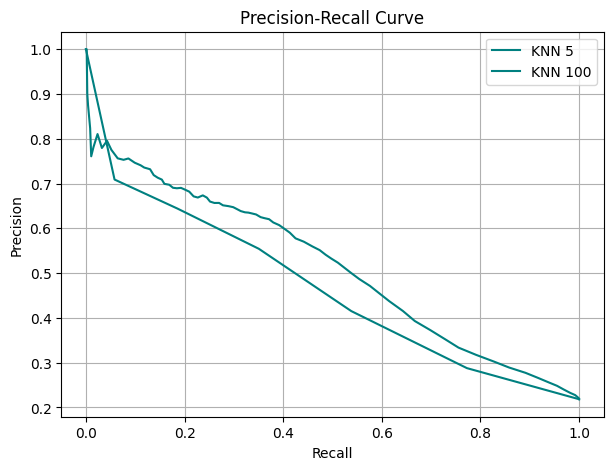

In [23]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
for m in models:
    curve_precision, curve_recall, _ = precision_recall_curve(y_test, probabilities[m][:,1])
    plt.plot(curve_recall, curve_precision, color='teal', label=m)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

Have a look at the plot. Suppose your project requires a model with good recall and the choice is between a KNN classifier with 5 neighbours or with 100 neighbors. What would be your advice?  
_Both recall and precision are better with 5 neighbours_

Assume that your project requires a model with a precision of at least 0.5. Which model has the highest recall under the requirement of a precision of at least 0.5 . What are the recalls of both models under this requirement?  
_Both recall and precision are better with 5 neighbours. With recall is 0.5 the precision is 0.53 with 5 neighbours and 0.42 with 100 neighbours._
